In [1]:
import pickle
import numpy as np
import pandas as pd
from pathlib import Path

from vebir.absorbance_estimators.vibes import VibeSpec
from vebir.interference_models.pca import pca, loo_pca
from vebir.utils.help_functions import vibes_help_fun

from tqdm import tqdm


In [2]:
REPO_ROOT = Path.cwd().resolve().parent
PREPROC_DIR = REPO_ROOT / "data" / "preprocessed" / "airmon"
CORRECTIONS_DIR = REPO_ROOT / "data" / "corrections" / "airmon"

cleaned_spectra_dict_path = PREPROC_DIR / "cleaned_spectra_dict.pkl"

with open(cleaned_spectra_dict_path, "rb") as f:
    cleaned_spectra_dict = pickle.load(f)

In [3]:
contaminated_names = [
        "20250603_ammoniumsulfate_calibration_3_A",
        "20250603_ammoniumsulfate_calibration_5_A",
        "20250605_ammoniumsulfate_calibration5k_3_A",
        "20250605_ammoniumsulfate_calibration5k_smallertime_5_A",
        "20250603_ammoniumsulfate_calibration_4_B",
        "20250604_ammoniumsulfate_calibration_10_B",
        "20250604_ammoniumsulfate_calibration_12_B",
        "ammonium_nitrate_calibration_5_A",
        "ammonium_nitrate_calibration_7_A",
        "ammonium_nitrate_calibration_6_B",
    ]

cleaned_crystal_types = [
        "ammonium_sulphate_calibration",
        "ammonium_nitrate_calibration",
        "japan",
        "ambient_measurements",
    ]

In [11]:
Z = pd.concat(
        [
            cleaned_spectra_dict[cleaned_crystal]
            for cleaned_crystal in cleaned_crystal_types
        ]
    )

Z.drop(index=contaminated_names, inplace=True)

In [12]:
len(contaminated_names)

10

In [13]:
Z.shape

(245, 2799)

In [181]:
target_crystals = np.array(Z.index[Z.index.str.contains("ammoniumsulfate|ammonium_nitrate", case=False, na=False)])
cleaned_crystal_loo = []

In [ ]:
for i in tqdm(range(len(target_crystals))):
    Zl = np.array(Z.drop(index=target_crystals[i]))
    _, loo_chat, _ = loo_pca(Zl)
    mu, _, _, W = pca(Zl)
    W = W[:, :loo_chat]
    
    args = (Z.loc[target_crystals[i]].values, mu, W, None, loo_chat, "PB", target_crystals[i])
    
    cleaned_crystal_loo.append(vibes_help_fun(args))

100%|██████████| 44/44 [1:19:39<00:00, 108.61s/it]


In [194]:
with open("../data/temp/cleaned_crystal_loo.pkl", "wb") as f:
    pickle.dump(cleaned_crystal_loo, f)

In [195]:
with open("../data/temp/cleaned_crystal_loo.pkl", "rb") as f:
    cleaned_crystal_loo = pickle.load(f)

In [196]:
np.argmax([i["sigma"] for i in cleaned_crystal_loo])

np.int64(11)

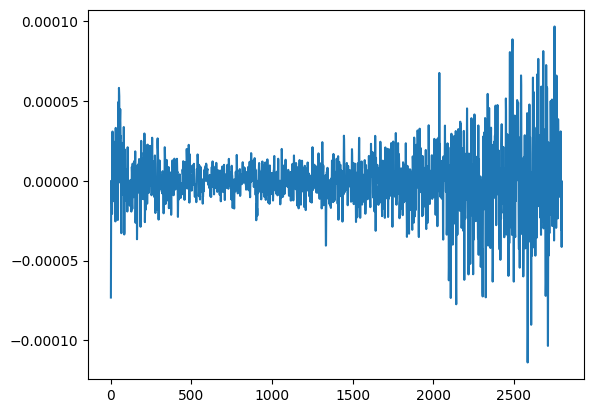

In [197]:
plt.plot(cleaned_crystal_loo[20]["absorbance"])

{'whiskers': [<matplotlib.lines.Line2D at 0x24c2f26a990>,
 'caps': [<matplotlib.lines.Line2D at 0x24c2f26ae40>,
 'boxes': [<matplotlib.lines.Line2D at 0x24c2f26a720>],
 'medians': [<matplotlib.lines.Line2D at 0x24c2f26b3b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x24c2f26b680>],
 'means': []}

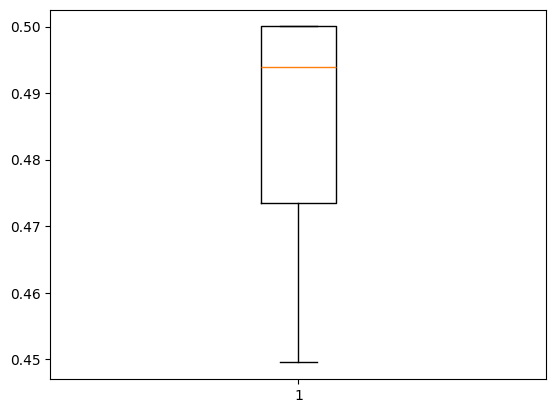

In [199]:
plt.boxplot([i["tau"] for i in cleaned_crystal_loo])

In [172]:
Zl = np.array(Z.drop(index=target_crystals[i]))
_, loo_chat, _ = loo_pca(Zl)
mu, _, _, W = pca(Zl)
W = W[:, :loo_chat]

args = (Z.loc[target_crystals[i]].values, mu, W, None, loo_chat, "PB", target_crystals[i])

In [173]:
vibes_help_fun(args)

{'sample_id': '20250603_ammoniumsulfate_calibration_1_A',
 'absorbance': array([-6.47614302e-06,  8.66630968e-06,  2.66555261e-05, ...,
        -1.17042182e-05, -6.68332056e-12,  6.31629530e-06], shape=(2799,)),
 'time': 75.0866448879242,
 'sigma': np.float64(6.375694789087375e-06),
 'tau': np.float64(0.4651834000076209),
 'c': np.int64(220),
 'x': array([-1.55035619e+00, -1.10925738e+00,  1.45807430e+00, -1.75305916e+00,
        -2.35259128e-01,  6.09142510e-01, -2.12493665e-01, -3.61647966e+00,
        -6.84626805e-01,  1.82682887e+00,  3.37546098e+00, -9.30234546e-01,
         4.32799638e+00, -2.90005746e+00, -2.12561611e+00, -1.46804329e+00,
        -2.31234658e+00,  4.93107781e-01, -9.26702292e-01, -3.53233587e-01,
        -1.09140195e+00,  1.16706622e-01,  2.51417979e-02, -1.70504257e-01,
         7.84968280e-01,  1.40582692e-01,  1.78227640e-01,  4.13937041e-01,
        -7.69022862e-01, -1.54011649e-01, -7.97573093e-01,  4.46223527e-01,
         2.03068922e-01, -6.36651964e-01, 

In [174]:
loo_chat

np.int64(220)

In [160]:
# def vibes_help_fun(args):
#     y, mu, W, tau, c, loss, sample_id = args

In [ ]:

#W = W[:, :loo_chat]

In [157]:
# def vibes_help_fun(args):
#     y, mu, W, tau, c, loss, sample_id = args
    
#     if tau is not None:
#         tau_min, tau_max = tau , tau
        
#     else:
#         tau_min, tau_max = 1e-5, 0.5 + 1e-5
    
#     elbos_grid = []
#     if c is None:
#         nu_init = np.array([0])
#         d_init = np.array([1])
        
#         if tau is not None:
#             tau_init = tau
#         else:
#             tau_init = 0.1
        
#         for i in range(W.shape[1]):
#             mod = VibeSpec(c = i+1,loss=loss,nu_init=nu_init,d_init=d_init,tau_init=tau_init) 
#             mod.fit(y, mu, W[:, : (i+1)], tau_min=tau_min, tau_max=tau_max,mit=500)
#             nu_init = np.append(mod.nu,0)
#             d_init = np.append(mod.d,1)
#             tau_init = mod.tau
#             elbos_grid.append(mod.elbo)
            
#     elbos_grid = np.array(elbos_grid)
#     c = np.argmax(elbos_grid) + 1        
            
#     W = W[:, :c]
#     mod = VibeSpec(c = c,loss=loss)
#     start = time.time()
#     mod.fit(y, mu, W, tau_min=tau_min, tau_max=tau_max)
#     z,x = mod.map_solver.solve(y,mu,W)
#     end = time.time()
    
#     res = {
#         "sample_id": sample_id,
#          "absorbance": y-z,
#          "time": end - start,
#          "sigma": mod.sigma_hat,
#          "tau":mod.tau,
#          "c": c,
#          "x": x,
#          "d": mod.d,
#          "nu": mod.nu,
#          "elbos_grid": elbos_grid,
#          "elbo": mod.elbo,
#     }

#     return res

In [158]:
# for i in range(len(c_grid)):
#         c = c_grid[i]
#         mod.c = c
#         mod.fit(y, mu, W[:, :c], mit=mit, tau_min=tau_min, tau_max=tau_max)
#         elbos.append(mod.elbo)

#         if elbos[-1] == np.max(elbos):
#             tau_init = mod.tau
#             chat = c
#             nu_init = mod.nu
#             d_init = mod.d

#         if i == len(c_grid) - 1:
#             break

#         mod.tau_init = mod.tau
#         mod.nu_init = np.append(mod.nu_init, np.zeros(c_grid[i + 1] - c))
#         mod.d_init = np.append(mod.d_init, np.ones(c_grid[i + 1] - c))